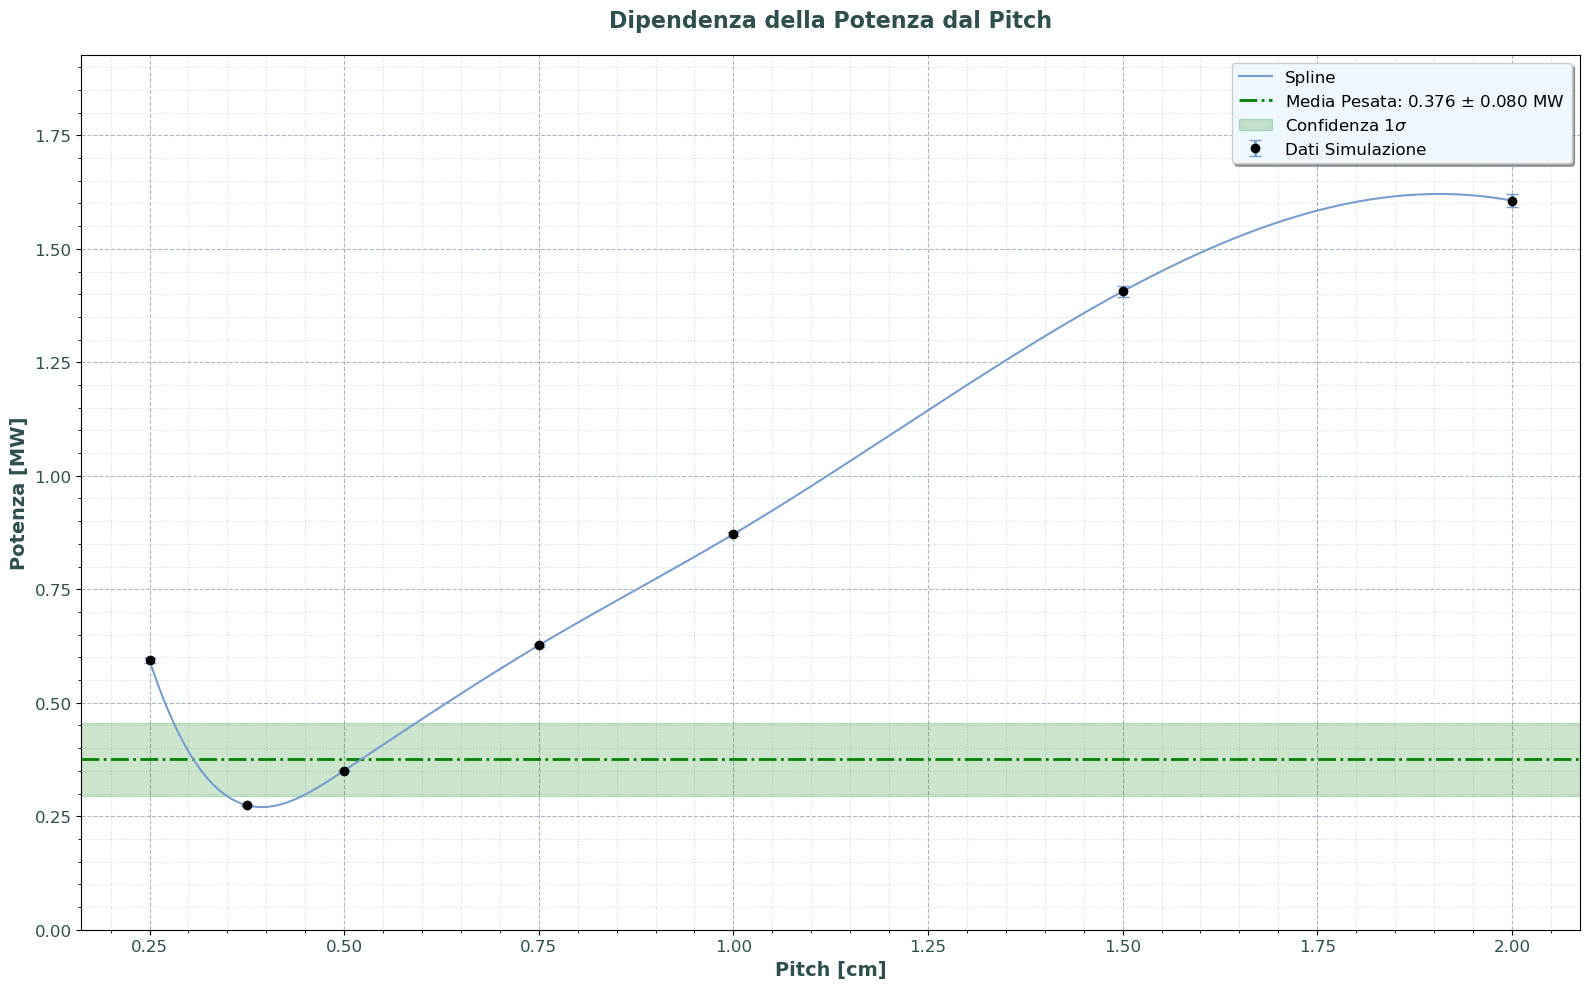

In [1]:
import glob
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import make_interp_spline
import openmc

E_FISSION_J = 200.0 * 1e6 * 1.6022e-19  # Energia media per fissione [J]
S_INTENSITY = 2.02e17                   # Fotoni/s dal sincrotrone

def analizza_potenza():
    """Legge i file .h5, estrae media e deviazione standard delle fissioni, calcola potenza e incertezza."""
    # Aggiornato per leggere i file dal formato fornito
    file_list = glob.glob("fixed/statepoints/statepoint_pitch_*.h5")
    
    if not file_list:
        print("Nessun file statepoint trovato nella cartella corrente.")
        return pd.DataFrame()
        
    dati = []
    # Regex per estrarre il pitch dal nome file (es. 0_750 -> 0.750)
    pattern = re.compile(r"statepoint_pitch_([\d_]+)\.h5")

    for file_sp in file_list:
        filename = os.path.basename(file_sp)
        match = pattern.search(filename)
        if not match:
            continue
            
        pitch_str = match.group(1).replace('_', '.')
        pitch = float(pitch_str)
        
        with openmc.StatePoint(file_sp) as sp:
            try:
                tally = sp.get_tally(name='fission_tot')
                fission_mean = tally.mean.flatten()[0]
                fission_std = tally.std_dev.flatten()[0] # Estrazione errore statistico
            except KeyError:
                print(f"Attenzione: Tally 'fission_tot' non trovato in {file_sp}")
                continue
                
        # Calcolo Potenza e Incertezza [MW]
        potenza_MW = (fission_mean * S_INTENSITY * E_FISSION_J) / 1e6
        errore_MW = (fission_std * S_INTENSITY * E_FISSION_J) / 1e6
        
        dati.append({
            'Pitch': pitch,
            'Potenza_MW': potenza_MW,
            'Errore_MW': errore_MW
        })
        
    return pd.DataFrame(dati)

def plot_scatter_smooth_err(df):
    """Genera plot a dispersione Potenza vs Pitch con styling rigoroso."""
    if df.empty:
        return
        
    fig, ax = plt.subplots(figsize=(16, 10))
    
    # Ordinamento in base al Pitch
    df = df.sort_values(by='Pitch')
    x = df['Pitch'].values
    y = df['Potenza_MW'].values
    y_err = df['Errore_MW'].values
    
    # Plot dei punti centrali con barre di errore
    ax.errorbar(x, y, yerr=y_err, fmt='o', color='#000000', ecolor='#789DD1', 
                elinewidth=2, capsize=4, zorder=5, label='Dati Simulazione')
    
    # Interpolazione spline
    if len(x) >= 3:
        x_smooth = np.linspace(x.min(), x.max(), 300)
        spline = make_interp_spline(x, y, k=3)
        y_smooth = spline(x_smooth)
        ax.plot(x_smooth, y_smooth, zorder=4, color='#789DD1', label='Spline')
    else:
        ax.plot(x, y, zorder=4, color='#789DD1', label='Line')

    # Calcolo rigoroso media pesata su tutto il dataset
    pesi = 1.0 / (df['Errore_MW']**2)
    media_pesata = np.sum(df['Potenza_MW'] * pesi) / np.sum(pesi)

    chi_quadro = np.sum(((df['Potenza_MW'] - media_pesata)**2) / (df['Errore_MW']**2))
    chi_ridotto = chi_quadro / max(1, len(df) - 1)
    errore_media = 1.0 / np.sqrt(np.sum(pesi))

    # Se chi_ridotto > 1, i dati variano più dell'errore statistico
    if chi_ridotto > 1:
        errore_media = errore_media * np.sqrt(chi_ridotto)
    
    # Aggiunta retta orizzontale verde e banda di confidenza
    ax.axhline(y=media_pesata, color='green', linestyle='-.', linewidth=2, 
               zorder=3, label=f'Media Pesata: {media_pesata:.3f} $\pm$ {errore_media:.3f} MW')
    ax.axhspan(ymin=media_pesata - errore_media, ymax=media_pesata + errore_media, 
               color='green', alpha=0.2, zorder=2, label=r'Confidenza $1\sigma$')
            
    # Formattazione
    ax.set_title('Dipendenza della Potenza dal Pitch', 
                 fontsize=16, fontweight='bold', color='#2F4F4F', pad=20)
    ax.set_xlabel('Pitch [cm]', fontsize=14, fontweight='bold', color='#2F4F4F')
    ax.set_ylabel('Potenza [MW]', fontsize=14, fontweight='bold', color='#2F4F4F')
    ax.tick_params(axis='both', which='major', labelsize=12, labelcolor='#2F4F4F')
    
    # Griglia avanzata
    ax.minorticks_on()
    ax.grid(which='major', linestyle='--', alpha=0.6, color='#778899')
    ax.grid(which='minor', linestyle=':', alpha=0.3, color='#778899')
    
    # Legenda
    ax.legend(loc='upper right', frameon=True, shadow=True, 
              fontsize=12, facecolor='#F0F8FF')

    plt.ylim(0.0, df['Potenza_MW'].max() * 1.2)
    
    plt.tight_layout()
    plt.savefig('scatter_potenza_pitch.png', dpi=300)

# Esecuzione
df_potenza = analizza_potenza()
plot_scatter_smooth_err(df_potenza)